# 1. Read and Visualize Data

In [83]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [84]:
df = pd.read_csv("Cricket.csv", sep=",", encoding="ISO-8859-1", header=0)
df.head()

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28


In [85]:
df.size

1027

In [86]:
df.isnull().sum()

Player    0
Span      0
Mat       0
Inns      0
NO        0
Runs      0
HS        0
Ave       0
BF        0
SR        0
100       0
50        0
0         0
dtype: int64

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


In [88]:
score_df = df[["Player", "Ave", "SR"]]
score_df.head()

,Player,Ave,SR
0,SR Tendulkar (INDIA),44.83,86.23
1,KC Sangakkara (Asia/ICC/SL),41.98,78.86
2,RT Ponting (AUS/ICC),42.03,80.39
3,ST Jayasuriya (Asia/SL),32.36,91.20
4,DPMD Jayawardene (Asia/SL),33.37,78.96


In [89]:
parameter_df = score_df[["Ave", "SR"]]

scaler = StandardScaler()
score_scaled_df = scaler.fit_transform(parameter_df)
score_scaled_df.shape

(79, 2)

In [90]:
score_scaled_df = pd.DataFrame(score_scaled_df)
score_scaled_df.columns = ["Average", "Strike Rate"]
score_scaled_df.head()

,Average,Strike Rate
0,1.072294,0.703152
1,0.587725,-0.044139
2,0.596226,0.110997
3,-1.047909,1.207091
4,-0.876185,-0.034000


In [91]:
score_scaled_df.size

158

In [92]:
kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(score_scaled_df)

KMeans(max_iter=50, n_clusters=4)

In [93]:
kmeans.labels_

array([2, 0, 0, 3, 1, 0, 0, 0, 0, 0, 0, 0, 3, 2, 1, 2, 1, 3, 0, 0, 3, 0,
       1, 0, 3, 2, 1, 3, 1, 0, 1, 1, 0, 1, 2, 1, 1, 0, 2, 0, 1, 1, 2, 1,
       1, 1, 0, 1, 1, 0, 3, 0, 1, 1, 1, 1, 0, 3, 1, 3, 1, 3, 0, 2, 2, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 3, 1], dtype=int32)

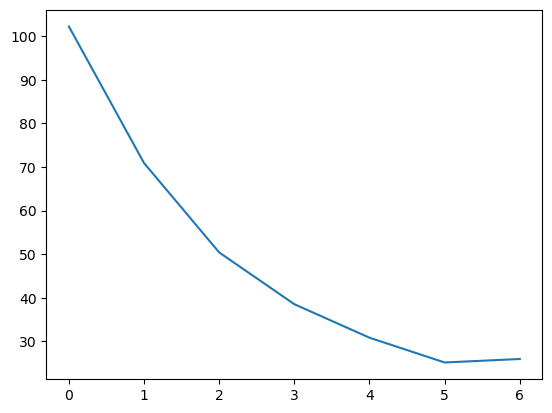

In [94]:
# elbow-curve/SSD
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(score_scaled_df)
    
    ssd.append(kmeans.inertia_)
    
# plot the SSDs for each n_clusters
# ssd
plt.plot(ssd)

In [95]:
# silhouette analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:
    
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50, random_state=100)
    kmeans.fit(score_scaled_df)
    
    cluster_labels = kmeans.labels_
    
    # silhouette score
    silhouette_avg = silhouette_score(score_scaled_df, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))
    
    

For n_clusters=2, the silhouette score is 0.37632823237612395
For n_clusters=3, the silhouette score is 0.378161484987122
For n_clusters=4, the silhouette score is 0.3673791553734254
For n_clusters=5, the silhouette score is 0.3641228035925646
For n_clusters=6, the silhouette score is 0.36586760989332046
For n_clusters=7, the silhouette score is 0.38301845780271
For n_clusters=8, the silhouette score is 0.3547254189799125


In [96]:
kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(score_scaled_df)

KMeans(max_iter=50, n_clusters=4)

In [97]:
kmeans.labels_

array([3, 1, 1, 2, 0, 1, 1, 1, 1, 1, 1, 1, 2, 3, 0, 3, 0, 1, 1, 1, 2, 1,
       0, 1, 2, 3, 0, 2, 0, 1, 0, 0, 1, 0, 3, 0, 0, 1, 3, 1, 0, 0, 3, 0,
       0, 0, 1, 0, 0, 1, 2, 1, 0, 0, 0, 0, 1, 2, 0, 2, 0, 2, 1, 3, 3, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 2, 0], dtype=int32)

In [98]:
score_df['cluster_id'] = kmeans.labels_
score_df.head()

/var/folders/_2/_ntp67w96yg93jqqp62sv22r0000gn/T/ipykernel_6938/4285057392.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  score_df['cluster_id'] = kmeans.labels_


,Player,Ave,SR,cluster_id
0,SR Tendulkar (INDIA),44.83,86.23,3
1,KC Sangakkara (Asia/ICC/SL),41.98,78.86,1
2,RT Ponting (AUS/ICC),42.03,80.39,1
3,ST Jayasuriya (Asia/SL),32.36,91.20,2
4,DPMD Jayawardene (Asia/SL),33.37,78.96,0


In [99]:
virat = score_df[score_df.Player == "V Kohli (INDIA)"]
virat

,Player,Ave,SR,cluster_id
25,V Kohli (INDIA),53.94,90.99,3


In [100]:
cluster_0 = score_df[score_df.cluster_id == 0]
cluster_0

,Player,Ave,SR,cluster_id
4,DPMD Jayawardene (Asia/SL),33.37,78.96,0
14,M Azharuddin (INDIA),36.92,74.02,0
16,PA de Silva (SL),34.90,81.13,0
22,MS Atapattu (SL),37.57,67.72,0
26,HH Gibbs (SA),36.13,83.26,0
28,SP Fleming (ICC/NZ),32.40,71.49,0
30,SR Waugh (AUS),32.90,75.91,0
31,A Ranatunga (SL),35.84,77.90,0
33,Younis Khan (PAK),31.24,75.29,0
35,Saleem Malik (PAK),32.88,76.41,0


In [120]:
sachin = score_df[score_df.Player == "SR Tendulkar (INDIA)"]
sachin

,Player,Ave,SR,cluster_id
0,SR Tendulkar (INDIA),44.83,86.23,3
